In [9]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import ToolMessage, HumanMessage

load_dotenv()

llm = ChatGroq(
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model="llama-3.3-70b-versatile",
    temperature=0.0
)

In [10]:
from pydantic import BaseModel, Field
from typing import Literal

class llm_schema(BaseModel):
    category: Literal['insta', 'twitter', 'linkedin'] = Field(..., description="Category of the post to generate")
    topic: str = Field(..., description="Topic of the post to generate")

llm_with_schema = llm.with_structured_output(llm_schema)

llm_with_schema.invoke("I want to generate a post for twitter about AI").category

'twitter'

In [ ]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    input: str
    topic: str
    post: str
    category: str

In [12]:
def decider_node(state: graph_schema) -> graph_schema:

    # Extract the input from the state
    user_input = state['input']

    # Passing the user input to the LLM to decide the category of the post to generate
    response = llm_with_schema.invoke(user_input) # Pydantic Object
    category = response.category # Extracting the category from the Pydantic Object
    topic = response.topic # Extracting the topic from the Pydantic Object

    # Update the state with the decided category and topic
    state['category'] = category
    state['topic'] = topic

    return state


def create_post_insta(state: graph_schema) -> graph_schema:


    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate an Instagram post
    post = llm.invoke(f"Write an Instagram post about {topic}. Keep the tone casual and engaging.").content

    # Update the state with the generated post
    state['post'] = post

    return {'post' : post}

def create_post_twitter(state: graph_schema) -> graph_schema:


    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a Twitter post
    post = llm.invoke(f"Write a Twitter post about {topic}. Keep the tone quick").content

    # Update the state with the generated post
    state['post'] = post

    return {'post' : post}


def create_post_linkedin(state: graph_schema) -> graph_schema:


    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a LinkedIn post
    post = llm.invoke(f"Write a LinkedIn post about {topic}. Keep the tone professional and informative.").content

    # Update the state with the generated post
    state['post'] = post

    return {'post' : post}

In [13]:
def condition(state: graph_schema) -> str:

    category = state['category']

    if category == 'insta':
        return 'create_insta'
    elif category == 'twitter':
        return 'create_twitter'
    elif category == 'linkedin':
        return 'create_linkedin'
    else:
        raise ValueError("Invalid category")

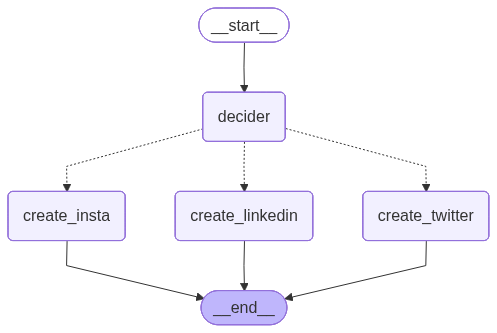

In [14]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("decider", decider_node)
graph.add_node("create_insta", create_post_insta)
graph.add_node("create_twitter", create_post_twitter)
graph.add_node("create_linkedin", create_post_linkedin)

graph.add_edge(START, "decider")
graph.add_conditional_edges("decider",condition,{
    'create_insta': "create_insta",
    'create_twitter': "create_twitter",
    'create_linkedin': "create_linkedin"
})

graph.add_edge("create_insta", END)
graph.add_edge("create_twitter", END)
graph.add_edge("create_linkedin", END)


route_graph = graph.compile()


from IPython.display import Image, display

# You could see the errors with the below command
Image(route_graph.get_graph().draw_mermaid_png())

In [15]:
route_graph.invoke({
    "input": "I want to generate a post for twitter about AI",
    "topic":"",
    "category":"",
    "post":""
})

{'input': 'I want to generate a post for twitter about AI',
 'topic': 'AI',
 'post': '"AI is changing the game. From chatbots to self-driving cars, the future is here. What\'s next? #AI #Innovation"',
 'category': 'twitter'}